<a href="https://colab.research.google.com/github/andersonmoraix/anotacoeseconometria/blob/main/A3_econometria_modelo3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importando as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.stattools import durbin_watson

In [ ]:
#lendo o arquivo(s)

caminho = '/content/iron_ore_2012_2022.xlsx'

# Minério
minerio = pd.read_excel(caminho, sheet_name='Minerio Preco')
minerio.columns = ['Data', 'Preco_Minerio']
minerio['Data'] = pd.to_datetime(minerio['Data'], format='%d.%m.%Y')
minerio['Data_fmt'] = minerio['Data'].dt.strftime('%Y.%m')

# PIB China
pib = pd.read_excel(caminho, sheet_name='PIB China')
pib.columns = ['Data_fmt', 'PIB_China']

# BDI
bdi = pd.read_excel(caminho, sheet_name='Balti Dry Index - Frete', skiprows=40, header=0)
bdi.columns = ['Data', 'BDI']
bdi = bdi.dropna()
bdi['Data'] = pd.to_datetime(bdi['Data'], format='%d.%m.%Y')
bdi['Data_fmt'] = bdi['Data'].dt.strftime('%Y.%m')
bdi['BDI'] = pd.to_numeric(bdi['BDI'], errors='coerce')

# Forçar chave para string
minerio['Data_fmt'] = minerio['Data_fmt'].astype(str)
pib['Data_fmt']     = pib['Data_fmt'].astype(str)
bdi['Data_fmt']     = bdi['Data_fmt'].astype(str)

print(f"Minério:   {len(minerio)} linhas")
print(f"PIB China: {len(pib)} linhas")
print(f"BDI:       {len(bdi)} linhas")

Minério:   132 linhas
PIB China: 132 linhas
BDI:       132 linhas


In [ ]:
#Merge

df = minerio[['Data', 'Data_fmt', 'Preco_Minerio']] \
    .merge(bdi[['Data_fmt', 'BDI']], on='Data_fmt') \
    .merge(pib, on='Data_fmt')

df = df.sort_values('Data').reset_index(drop=True)

print(f"Total de observações: {len(df)}")
print(df[['Data_fmt', 'Preco_Minerio', 'BDI', 'PIB_China']].head())

Total de observações: 121
  Data_fmt  Preco_Minerio   BDI  PIB_China
0  2012.01          140.4   680   7.856174
1  2012.02          144.6   750   7.849720
2  2012.03          136.3   923   7.843266
3  2012.04          147.6  1155   7.836812
4  2012.05          127.9  1004   7.830358


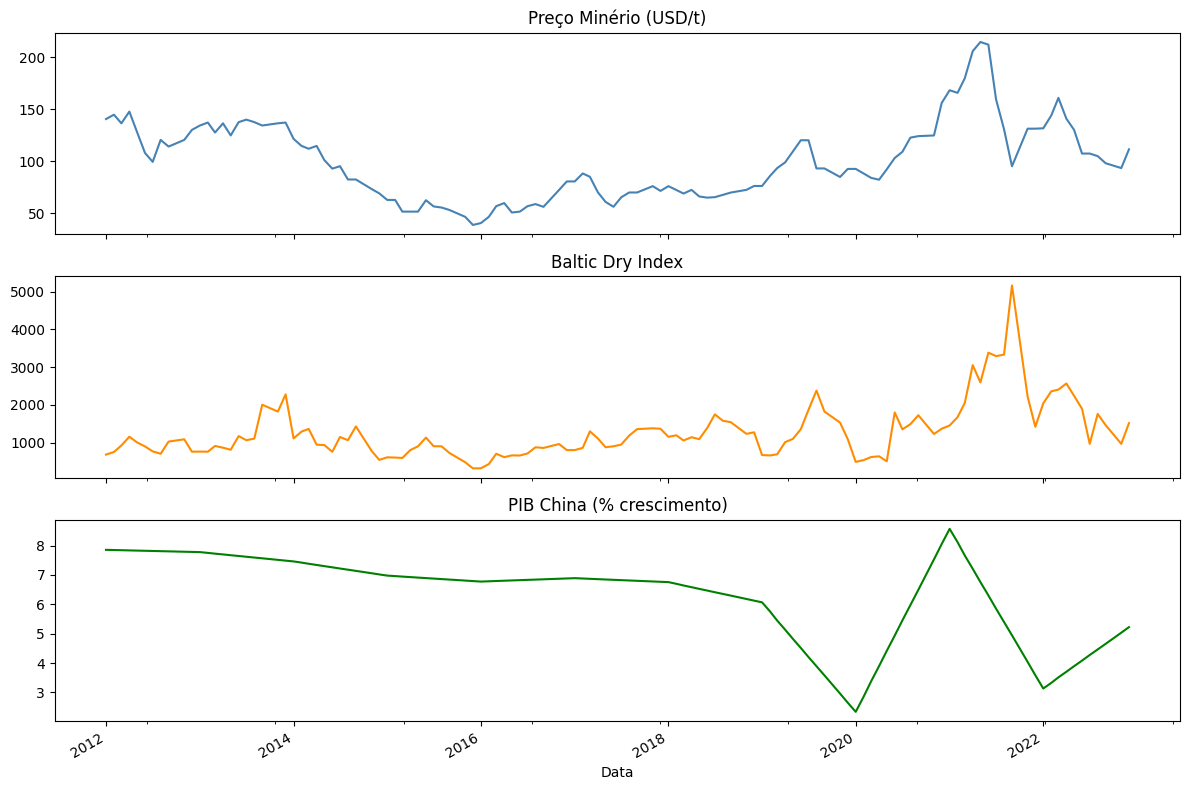

In [ ]:
#grafico das series

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

df.plot(x='Data', y='Preco_Minerio', ax=axes[0], title='Preço Minério (USD/t)',     legend=False, color='steelblue')
df.plot(x='Data', y='BDI',           ax=axes[1], title='Baltic Dry Index',           legend=False, color='darkorange')
df.plot(x='Data', y='PIB_China',     ax=axes[2], title='PIB China (% crescimento)', legend=False, color='green')

plt.tight_layout()
plt.show()

In [ ]:
#rodando a regressão

# Y = Preço Minério | X1 = BDI | X2 = PIB China
modelo = smf.ols('Preco_Minerio ~ BDI + PIB_China', data=df)
resultado = modelo.fit()
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:          Preco_Minerio   R-squared:                       0.319
Model:                            OLS   Adj. R-squared:                  0.308
Method:                 Least Squares   F-statistic:                     27.65
Date:                Sun, 31 May 2026   Prob (F-statistic):           1.42e-10
Time:                        23:22:24   Log-Likelihood:                -586.17
No. Observations:                 121   AIC:                             1178.
Df Residuals:                     118   BIC:                             1187.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     29.6792     15.386      1.929      0.0

Durbin-Watson: 0.4013
(~2 = sem autocorrelação | <1 = positiva | >3 = negativa)


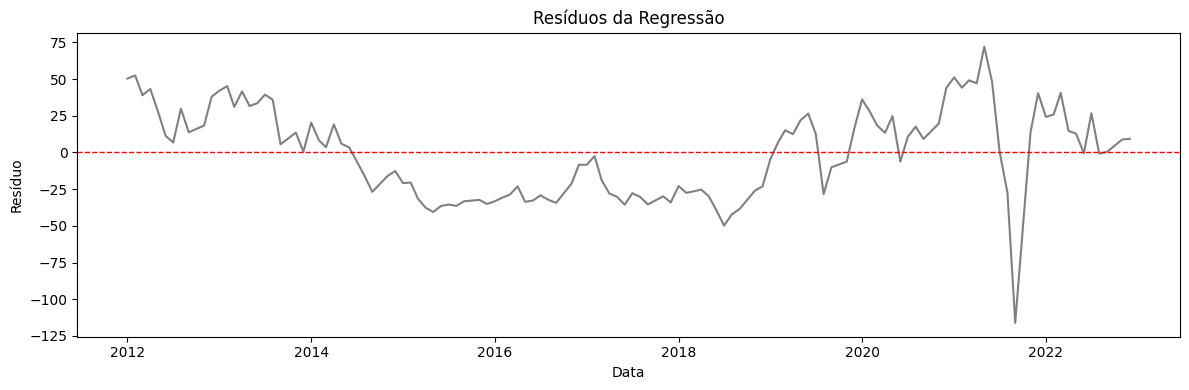


R²          = 0.3191
R² ajustado = 0.3075

Coeficientes:
Intercept    29.6792
BDI           0.0303
PIB_China     5.0631
dtype: float64

P-valores:
Intercept    0.0561
BDI          0.0000
PIB_China    0.0144
dtype: float64


In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(resultado.resid)
print(f"Durbin-Watson: {dw:.4f}")
print("(~2 = sem autocorrelação | <1 = positiva | >3 = negativa)")

plt.figure(figsize=(12, 4))
plt.plot(df['Data'], resultado.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos da Regressão')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado.rsquared:.4f}")
print(f"R² ajustado = {resultado.rsquared_adj:.4f}")
print(f"\nCoeficientes:\n{resultado.params.round(4)}")
print(f"\nP-valores:\n{resultado.pvalues.round(4)}")

In [ ]:
#Estimando o Prô

# Criar variáveis defasadas (t-1)
df['Preco_Minerio_lag'] = df['Preco_Minerio'].shift(1)
df['BDI_lag']           = df['BDI'].shift(1)
df['PIB_China_lag']     = df['PIB_China'].shift(1)

# Remove primeira linha com NaN
df_lag = df.dropna().copy()

# Regredir com defasadas para estimar o rô
modelo_rho = smf.ols(
    'Preco_Minerio ~ Preco_Minerio_lag + BDI + BDI_lag + PIB_China + PIB_China_lag',
    data=df_lag
)
resultado_rho = modelo_rho.fit()

# O rô é o coeficiente de Preco_Minerio_lag
rho = resultado_rho.params['Preco_Minerio_lag']
print(f"ρ (rô) estimado = {rho:.4f}")

ρ (rô) estimado = 0.9760


In [ ]:
# W = Y_t - ρ * Y_(t-1)
# Z = X_t - ρ * X_(t-1)
df_lag['W']       = df_lag['Preco_Minerio'] - rho * df_lag['Preco_Minerio_lag']
df_lag['Z_BDI']   = df_lag['BDI']           - rho * df_lag['BDI_lag']
df_lag['Z_PIB']   = df_lag['PIB_China']     - rho * df_lag['PIB_China_lag']

print("Variáveis transformadas:")
print(df_lag[['Data_fmt', 'W', 'Z_BDI', 'Z_PIB']].head())

Variáveis transformadas:
  Data_fmt          W       Z_BDI     Z_PIB
1  2012.02   7.568880   86.316514  0.182054
2  2012.03  -4.830341  190.996155  0.181899
3  2012.04  14.570501  254.147268  0.181744
4  2012.05 -16.158357 -123.285921  0.181589
5  2012.06 -17.031056  -82.909147  0.181434


In [ ]:
modelo_corrigido = smf.ols('W ~ Z_BDI + Z_PIB', data=df_lag)
resultado_corrigido = modelo_corrigido.fit()
print(resultado_corrigido.summary())

                            OLS Regression Results                            
Dep. Variable:                      W   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.156
Date:                Sun, 31 May 2026   Prob (F-statistic):              0.318
Time:                        23:31:55   Log-Likelihood:                -463.95
No. Observations:                 120   AIC:                             933.9
Df Residuals:                     117   BIC:                             942.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.6787      1.191      1.409      0.1

Durbin-Watson original:  0.401  ← autocorrelação grave
Durbin-Watson corrigido: 1.5790  ← deve estar próximo de 2


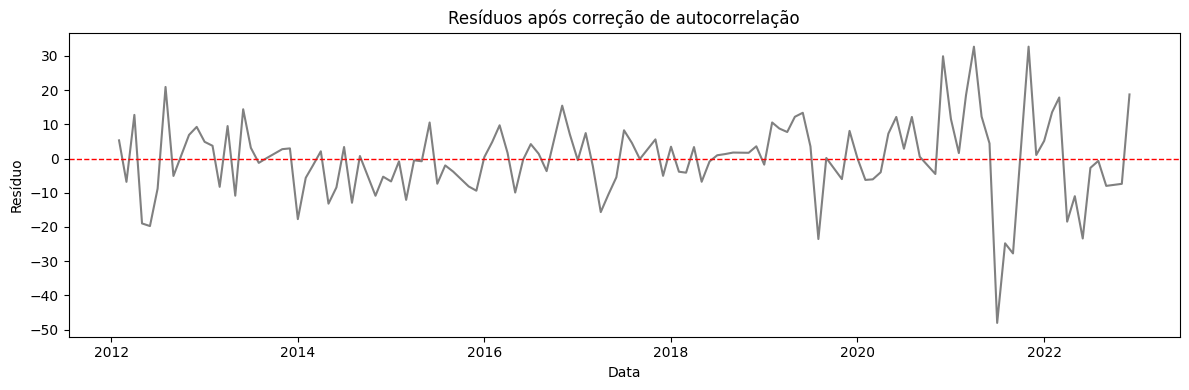


R²          = 0.0194
R² ajustado = 0.0026

Coeficientes:
Intercept    1.6787
Z_BDI       -0.0027
Z_PIB        4.3789
dtype: float64

P-valores:
Intercept    0.1614
Z_BDI        0.2473
Z_PIB        0.2822
dtype: float64


In [ ]:
dw_corrigido = durbin_watson(resultado_corrigido.resid)

print(f"Durbin-Watson original:  0.401  ← autocorrelação grave")
print(f"Durbin-Watson corrigido: {dw_corrigido:.4f}  ← deve estar próximo de 2")

plt.figure(figsize=(12, 4))
plt.plot(df_lag['Data'].values, resultado_corrigido.resid, color='gray')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Resíduos após correção de autocorrelação')
plt.xlabel('Data')
plt.ylabel('Resíduo')
plt.tight_layout()
plt.show()

print(f"\nR²          = {resultado_corrigido.rsquared:.4f}")
print(f"R² ajustado = {resultado_corrigido.rsquared_adj:.4f}")
print(f"\nCoeficientes:\n{resultado_corrigido.params.round(4)}")
print(f"\nP-valores:\n{resultado_corrigido.pvalues.round(4)}")